In [27]:
import numpy as np
import pandas as pd
import plotly.express as px 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score , mean_squared_error

In [28]:
df = pd.read_csv('house_prices_practice.csv')

In [29]:
df.head(5)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [30]:
df['FullBath'].unique().sum()

np.int64(6)

In [31]:
df.isnull().sum()

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64

In [32]:
df.drop(columns=['Id'] , axis=1 , inplace=True)

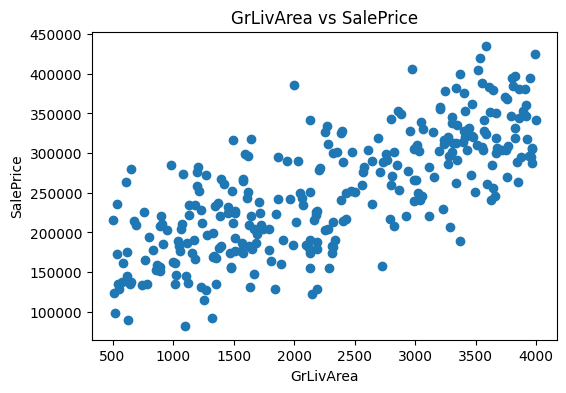

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("GrLivArea vs SalePrice")
plt.show()


Text(0, 0.5, 'SalePrice')

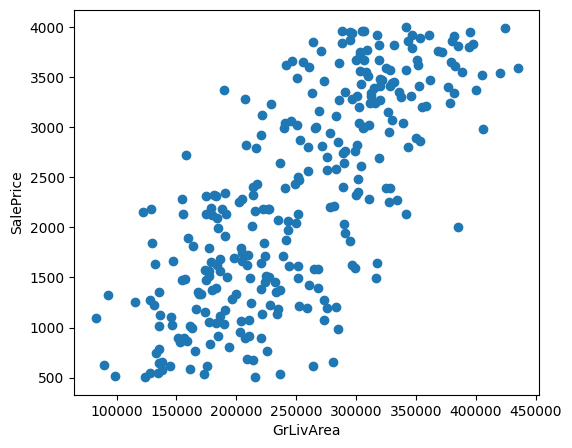

In [34]:
plt.figure(figsize=(6,5))
plt.scatter(df['SalePrice'],df['GrLivArea'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

In [35]:
x = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [36]:
y

0      177106
1      301044
2      360609
3      240556
4      193656
        ...  
295    250604
296    329906
297    184623
298    303345
299    204982
Name: SalePrice, Length: 300, dtype: int64

In [37]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size= 0.2,random_state=42 )

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
#scaler = StandardScaler()
#scaler.fit(x_train)

#x_train_scaled = scaler.transform(x_train)
#x_test_scaled = scaler.transform(x_test)



In [41]:
line_model = LinearRegression() 
line_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred = line_model.predict(x_test)
y_pred

array([239161.36318912, 190489.66798468, 398000.95746314, 223169.46755225,
       135188.39570786, 180259.03980676, 283708.27101141, 204535.26547718,
       205837.94173062, 171505.33195999, 389527.70178374, 274163.79739932,
       116220.90212357, 171343.53163323, 293879.4318867 , 314821.03156748,
       154945.46275533, 146162.96860437, 221221.02813414, 255128.9486496 ,
       235772.5157203 , 167430.54266849, 208978.16707484, 289813.4757898 ,
       313188.74897607, 382651.91313186, 206610.720434  , 260775.03716677,
       285214.27337024, 443345.98671709, 402224.27697766, 292287.65157279,
       122222.0857363 , 211039.07225073, 291045.64445758, 226581.77285369,
       342146.60151077, 243378.66853477, 235856.80880211, 201521.50903895,
       237379.06138587, 334582.4670175 , 313689.69084593, 292464.38340658,
       376959.34215332, 319400.67913445, 217324.69316315, 256908.21155235,
       218997.8110662 , 332431.87339145, 305659.98833243, 321564.58478163,
       110394.39792686, 3

In [43]:
from sklearn.metrics import mean_squared_error, r2_score ,root_mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)


RMSE: 12505.459264618976
R2 Score: 0.9724369952260821


In [44]:
y_train_pred = line_model.predict(x_train)

from sklearn.metrics import r2_score
print("Train R2:", r2_score(y_train, y_train_pred))


Train R2: 0.97903560732947


In [45]:
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Weight': line_model.coef_
}).sort_values(by='Weight', ascending=False)

coef_df


,Feature,Weight
2,GarageCars,19109.641614
0,OverallQual,11914.688135
5,FullBath,11040.343046
6,BedroomAbvGr,4812.061994
4,YearBuilt,746.370978
1,GrLivArea,55.410257
3,TotalBsmtSF,25.199018
7,LotArea,-0.159522


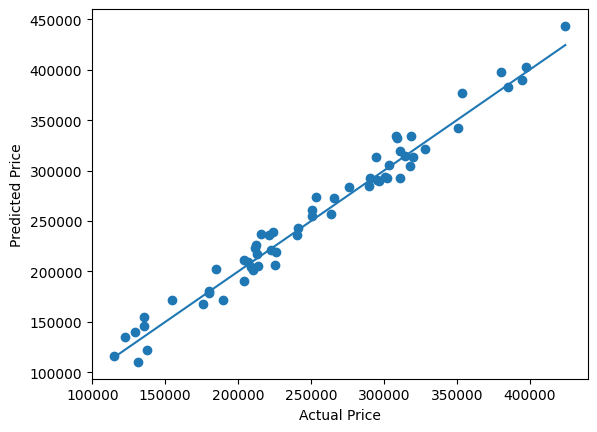

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()


In [47]:
import plotly.graph_objects as go

error = abs(y_test - y_pred)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test,
    y=y_pred,
    mode='markers',
    name='Predicted Prices',
    marker=dict(
        size=7,
        color=error,
        colorscale='Viridis',
        colorbar=dict(title='Absolute Error'),
        opacity=0.7
    )
))

fig.add_trace(go.Scatter(
    x=[y_test.min(), y_test.max()],
    y=[y_test.min(), y_test.max()],
    mode='lines',
    name='Perfect Prediction (y = x)',
    line=dict(
        width=3,
        dash='dash'
    )
))

fig.update_layout(
    title='Actual vs Predicted House Prices',
    xaxis_title='Actual Sale Price',
    yaxis_title='Predicted Sale Price',
    legend_title='Legend',
    template='plotly_white',
    width=800,
    height=650
)

fig.show()


In [48]:
import plotly.graph_objects as go

features = [
    'GarageCars',
    'OverallQual',
    'FullBath',
    'BedroomAbvGr',
    'YearBuilt',
    'GrLivArea',
    'TotalBsmtSF',
    'LotArea'
]

weights = [
    19109.641614,
    11914.688135,
    11040.343046,
    4812.061994,
    746.370978,
    55.410257,
    25.199018,
    -0.159522
]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=weights,
    y=features,
    orientation='h',
    marker=dict(
        color=weights,
        colorscale='RdBu',
        colorbar=dict(title='Weight')
    ),
    name='Feature Weight'
))

fig.update_layout(
    title='Feature Importance (Linear Regression Weights)',
    xaxis_title='Weight',
    yaxis_title='Feature',
    template='plotly_white',
    width=900,
    height=500
)

fig.show()


In [52]:
x_test.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea
203,6,1456,2,2297,1958,3,2,2661
266,1,1796,1,2234,1998,2,1,10453
152,6,3856,3,1201,2022,1,4,8602
9,5,1492,1,2175,2011,1,2,11218
233,1,2149,0,394,1979,2,2,10555


In [50]:
y_pred = line_model.predict(x_test)
mes = mean_squared_error(y_test,y_pred)
rsq = root_mean_squared_error(y_test,y_pred)
rsq 

12505.459264618976

In [58]:
import joblib

joblib.dump(line_model, r"E:\AMIT\DEPI_AIS2_G3_ml\src\ML\Session_2\linear_model.pkl")


['E:\\AMIT\\DEPI_AIS2_G3_ml\\src\\ML\\Session_2\\linear_model.pkl']